#Assignment 1

Max collaborators = 3

There is a bit of handholding. If you still do not understand something, feel free to reach out to your lab faculties. Good luck.

In [ ]:
COLLABORATORS_NAME = "Mehrin Afroz Lopa"
COLLABORATORS_ID = "22299547"

COLLABORATORS_NAME = "Nisat Nisa"
COLLABORATORS_ID = "22299095"

COLLABORATORS_NAME = "Nasaba Saif Audree"
COLLABORATORS_ID = "22201612"

# Part 1 [15 Marks]

In this part, you will work with point processing, HE, AHE, and CLAHE.

In [ ]:
pip install scikit-image

In [ ]:
import numpy as np
from skimage import io, color, exposure
import matplotlib.pyplot as plt
### If you need other dependencies import here -
from skimage import transform, img_as_float
### Code ends

In [ ]:
### If you need helper functions defined, define here -

### Code ends

## Task 1 - Basic Image Operation

Import any photograph taken by you (RGB) (`sample_1.jpeg`/`sample_1.jpg`) as a numpy array, save it in the varaible `I`.

A picture taken from your phone of any scenary/streets/building is better.

Remember - your image name MUST be `sample_1.jpeg`/`sample_1.jpg`.

Make sure the height and the width of the image is **smaller than 1000 pixels**.

In [ ]:
I = I = io.imread("/content/sample_data/Sample1.jpg")


# find the height and the width of the image
H = I.shape[0] # should contain height
W = I.shape[1] # should contain width
print("Height is", H)
print("Width is", W)

Height is 800
Width is 592


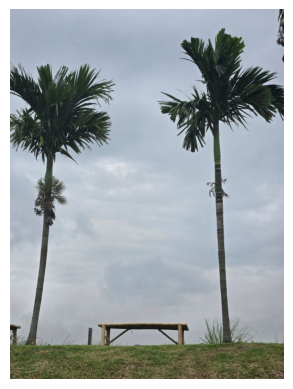

In [ ]:
I = img_as_float(I) # Replace none and normalize the image so that the pixel values of each channel are between 0 and 1

### Write a code to display the image -
plt.imshow(I)
plt.axis("off");
### Code ends

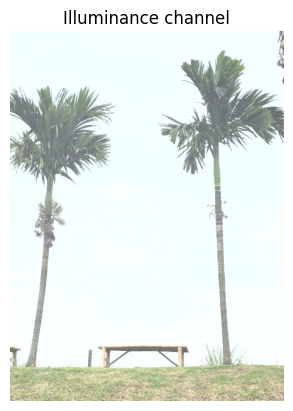

In [ ]:
# Increase the brightness of the image without changing the contrast.
# Save the resulting image in I_bright.
I_bright = None

### Hint - You have to convert to LAB first

### Write a code to display the I_bright -
Ilab = color.rgb2lab(I)
I_bright = np.clip(Ilab[:, :, 0] + 40, 0, 100)# chose c = 40

I_bright_lab = Ilab.copy()
I_bright_lab[:, :, 0] = I_bright
I_bright = color.lab2rgb(I_bright_lab)

plt.imshow(I_bright)
plt.title('Illuminance channel')
plt.axis('off');
### Code ends

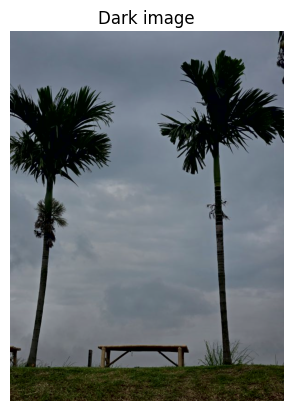

In [ ]:
# Decrease the brightness of the image without changing the contrast.
# Save the resulting image in I_dark.
I_dark = None

### Write a code to display the I_bright -
Ilab = color.rgb2lab(I)
I_dark = np.clip(Ilab[:, :, 0] - 22, 0, 100)# chose c = 22

I_dark_lab = Ilab.copy()
I_dark_lab[:, :, 0] = I_dark
I_dark = color.lab2rgb(I_dark_lab)

plt.imshow(I_dark)
plt.title('Dark image')
plt.axis('off');
### Code ends

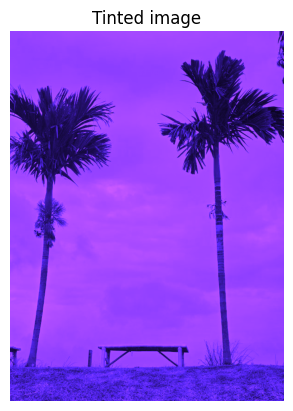

In [ ]:
# Multiply the three channels of image I with three DIFFERENT numbers between 0.3 and 3
# Save the resulting image in I_tint and display it.
# The resulting image should have some color shift
I_tint = None

### Write a code to display the I_tint -
I_tint = I.copy()
I_tint[:, :, 0] = I[:, :, 0] * 0.9#0.9,0.4, 2.7 are values from 0.3 to 3
I_tint[:, :, 1] = I[:, :, 0] * 0.4
I_tint[:, :, 2] = I[:, :, 0] * 2.7

I_tint = np.clip(I_tint, 0, 1)

plt.imshow(I_tint)
plt.title('Tinted image')
plt.axis('off');
### Code ends

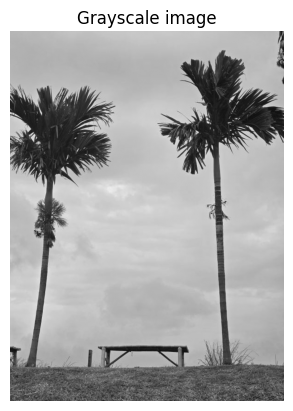

In [ ]:
# Convert the image into a grayscale image.
# Save it to I_gray and display it
I_gray = None

### Write a code to display the I_gray -
I_gray = color.rgb2gray(I)

plt.imshow(I_gray, cmap = 'grey')
plt.title('Grayscale image')
plt.axis('off');
### Code ends

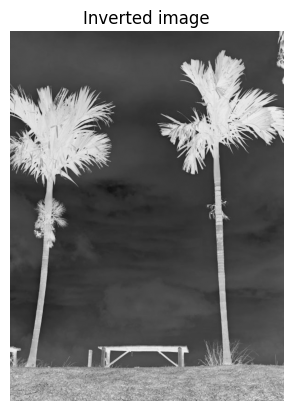

In [ ]:
# Display the negative of the grayscale image
I_neg = None

### Write a code to display the I_neg -
I_neg  = 1 - I_gray

plt.imshow(I_neg, cmap = 'grey');
plt.axis("off");
plt.title('Inverted image');
### Code ends

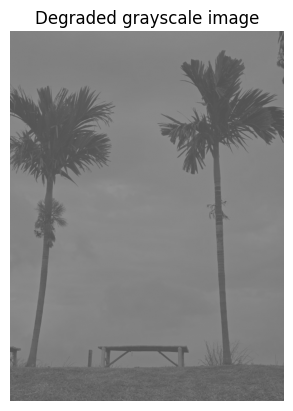

In [ ]:
# This cell will artificially degrade your grayscale image by reducing contrast
# The max pixel value is mapped to 0.6 and the min pixel value is mapped to 0.3
I_degraded = exposure.rescale_intensity(I_gray, in_range=(0, 1), out_range=(0.3, 0.6))
#contrast is compressed

# Try to understand what is going on
# You will need to use this concept later on

### Write a code to display the I_degraded -

# If you use plt.imshow(), set vmin = 0, vmax = 1

plt.imshow(I_degraded, cmap = 'grey', vmin = 0, vmax = 1);
plt.axis("off");
plt.title('Degraded grayscale image');
### Code ends

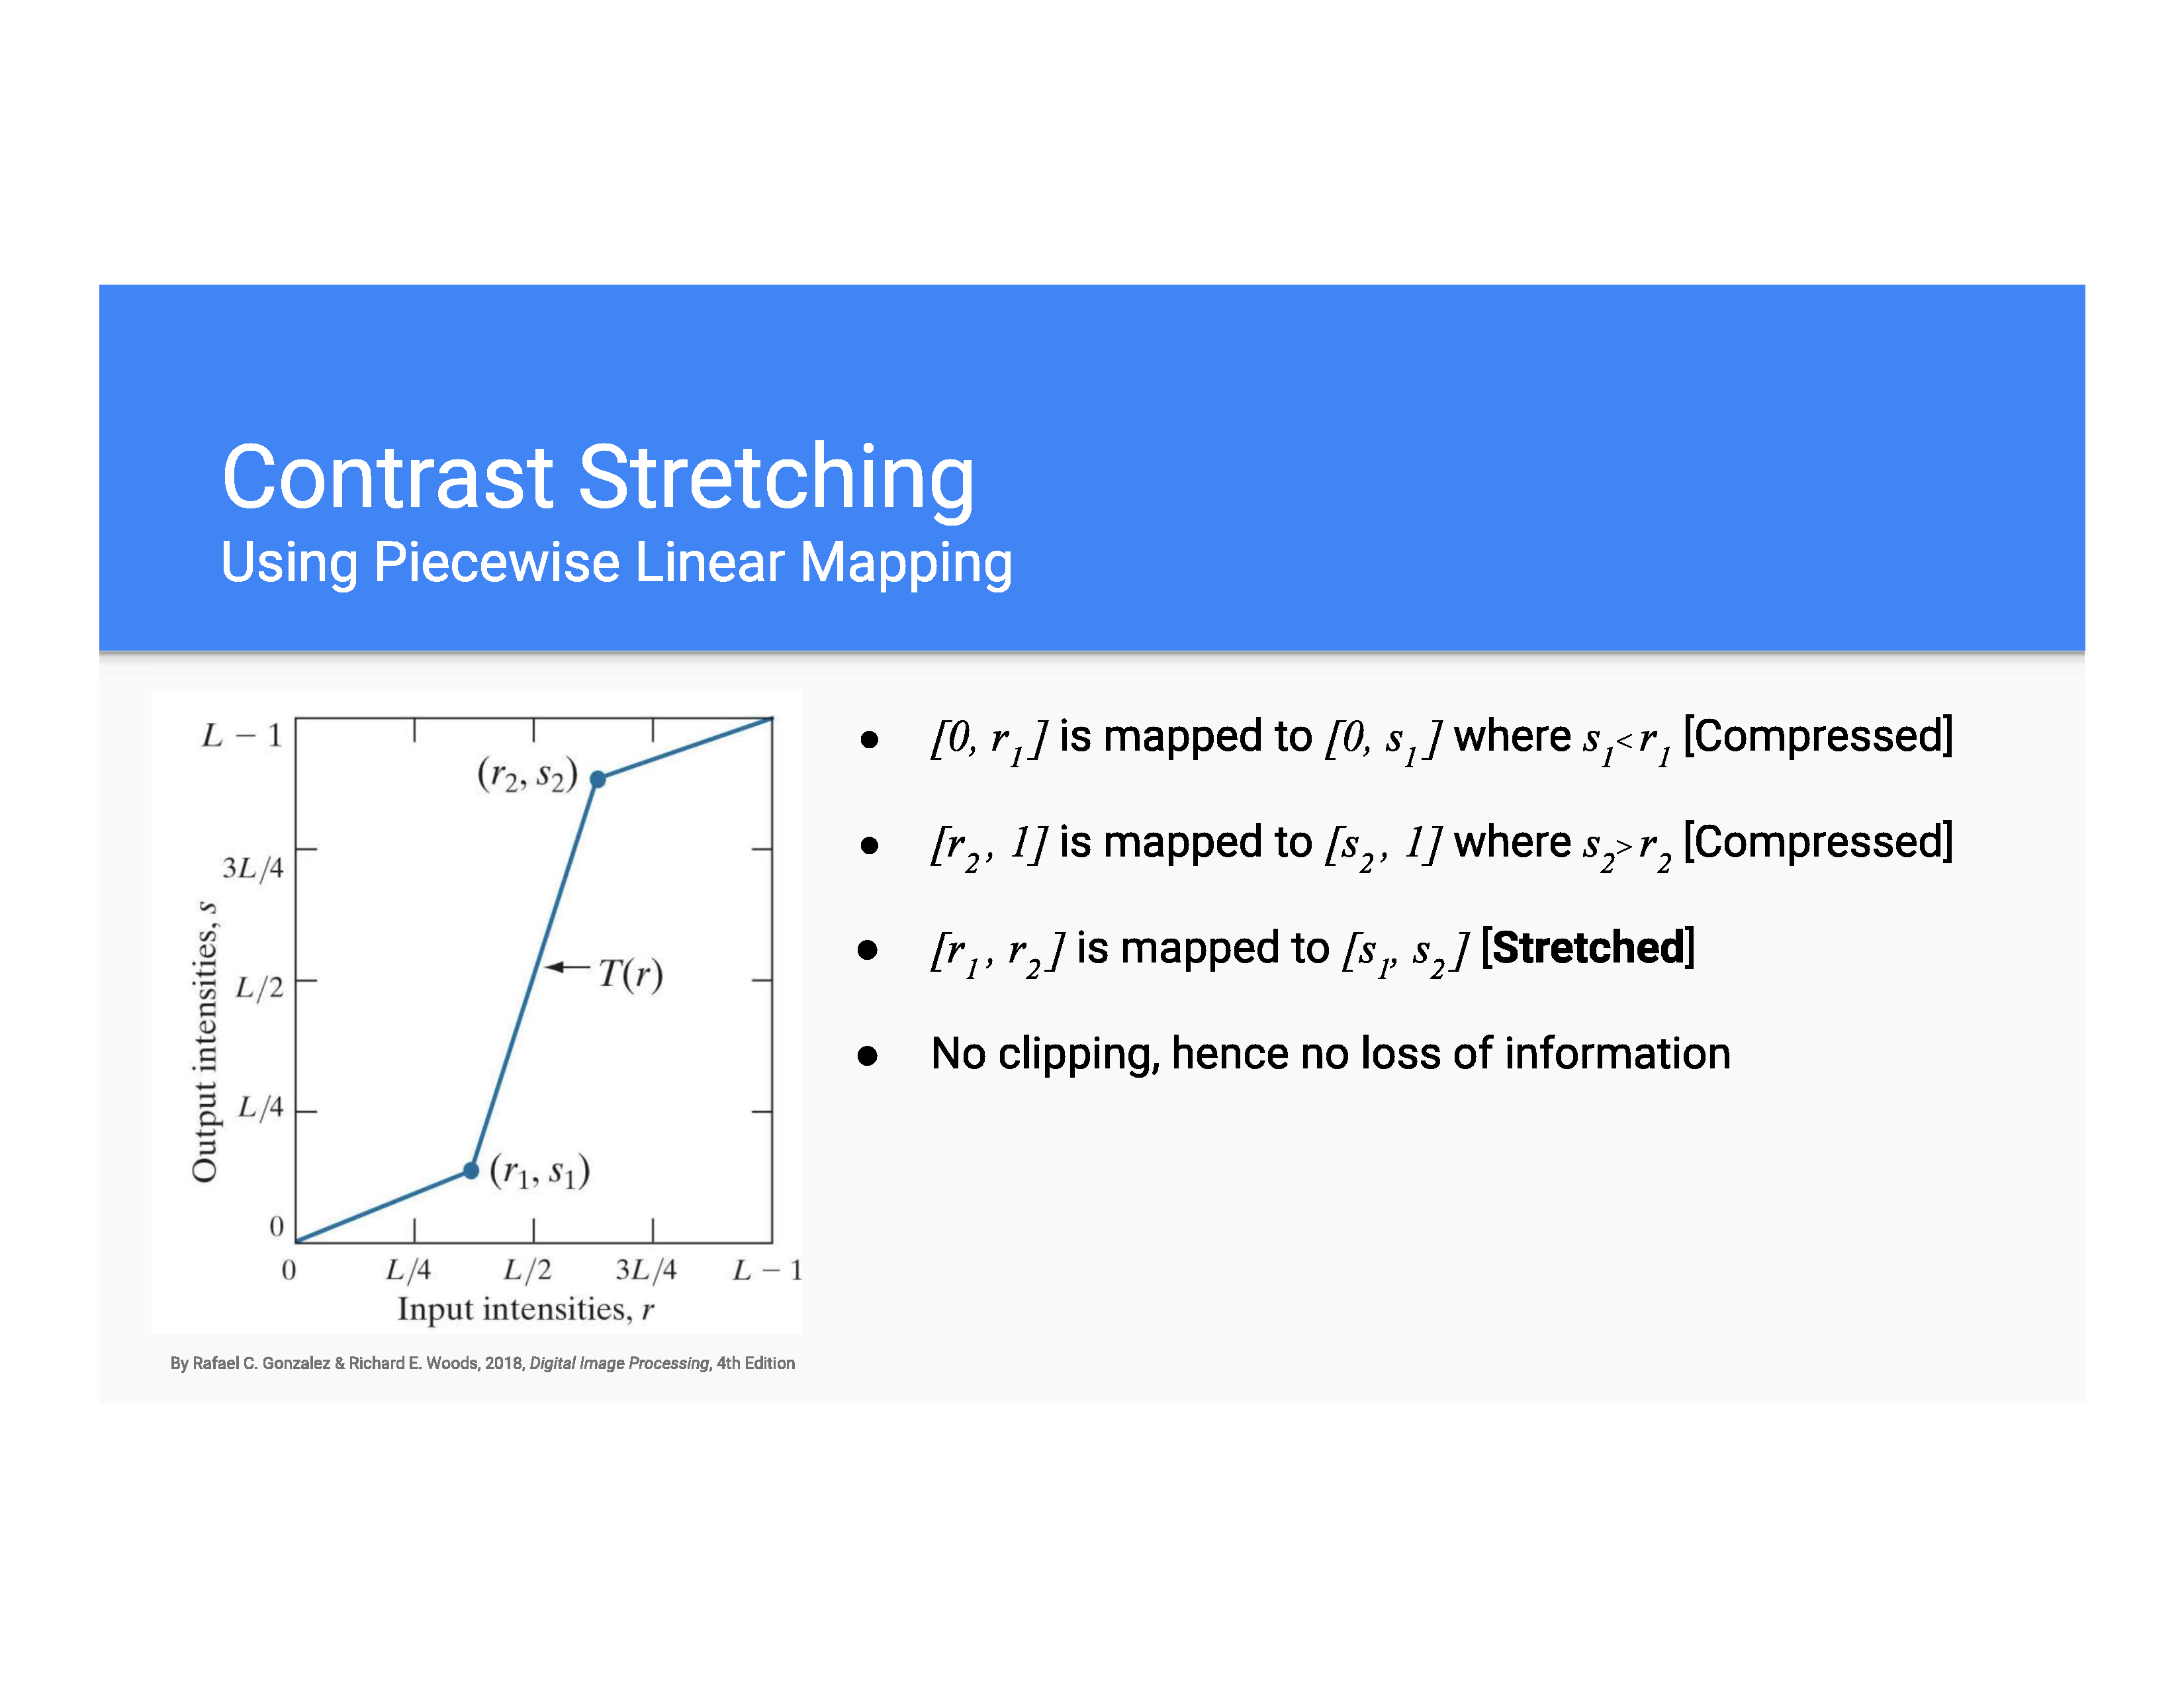

In [ ]:
# Complete the following function to perform Piecewise Linear Contrast stretching
# That is, implement the map shown in the picture above

# Assume both input and output images are normalized between 0 and 1

def piecewise_contrast_stretch(I, r1, r2, s1, s2):
    # Write your code here
    I_stretched = np.zeros(I.shape, dtype=I.dtype) # replace with appropriate code

    if r1 > s1 and r1 != 0:
        slope_m1 = (0-s1)/(0-r1)
    else:
        slope_m1 = 0

    slope_m2 = (s2-s1)/(r2-r1)

    if r2 < s2 and r2 != 0:
        slope_m3 = (1-s1)/(1-r1)
    else:
        slope_m3 = 0


    for i in range(I.shape[0]):
        for j in range(I.shape[1]):
            pixel= I[i, j]

            if pixel < r1:
                new_value = slope_m1 * pixel + 0

            elif pixel < r2:
                new_value = slope_m2 * (pixel - r1) + s1

            else:
                new_value = slope_m3 * (pixel - r2) + s2

            I_stretched[i, j] = new_value

    return I_stretched

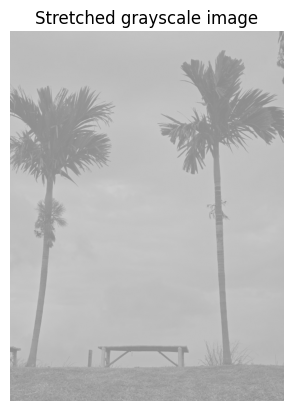

In [ ]:
# To test your implementation, contrast strech the degraded image I_degrade to fix it
r1 = 0.22
r2 = 0.3
s1 = 0.2
s2 = 0.53
I_stretched = piecewise_contrast_stretch(I_degraded, r1, r2, s1, s2)

### Write a code to display the I_stretched -
plt.imshow(I_stretched, cmap = 'grey', vmin = 0, vmax = 1);
plt.axis("off");
plt.title('Stretched grayscale image');
### Code ends

## Task 2 - Histogram and Equalization

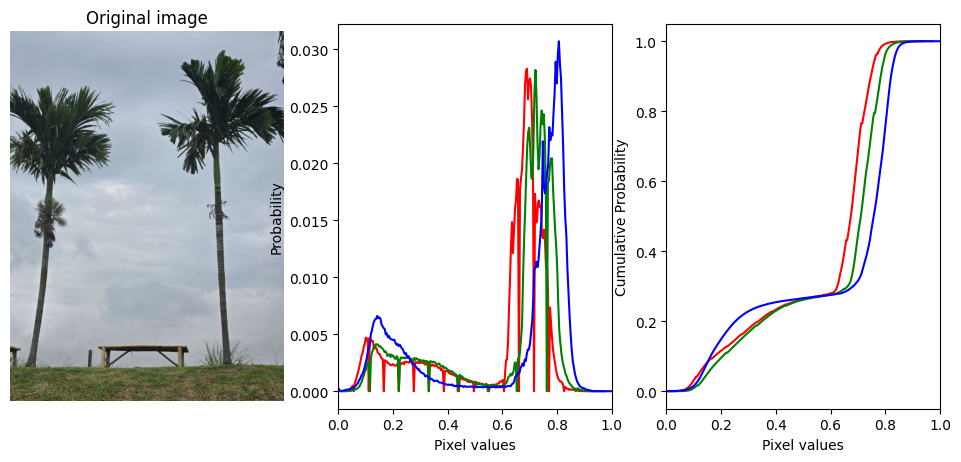

In [ ]:
# Plot the image and its histogram + cdf of the original image I
# Note that it is a color image, so it will have three different histograms

### Begin solution

plt.figure(figsize=(12,5))
plt.subplot(1, 3, 1)
plt.imshow(I);
plt.axis("off");
plt.title('Original image');


def plot_pdf(I, nbins=256, normalize=False):
    color=['r', 'g', 'b']

    plt.subplot(1, 3, 2)

    for i in range(3):

        hist, bins_hist = exposure.histogram(I[:, :, i].ravel(), nbins=nbins, normalize=normalize)
        plt.plot(bins_hist, hist, color[i])

    plt.xlabel("Pixel values")
    if normalize:
        plt.ylabel("Probability")
    else:
        plt.ylabel("Count")
    xmax = 1 if I.max() <= 1 else 255
    plt.xlim([0, xmax])

def plot_cdf(I, nbins=256, normalize=False):
    color=['r', 'g', 'b']

    plt.subplot(1, 3, 3)

    for i in range(3):

        img_cdf, bins = exposure.cumulative_distribution(I[:, :, i].ravel(), nbins=nbins)
        plt.plot(bins, img_cdf, color[i])

    plt.xlabel("Pixel values")
    if normalize:
        plt.ylabel("Cumulative Probability")
    else:
        plt.ylabel("Count")

    xmax = 1 if I.max() <= 1 else 255
    plt.xlim([0, xmax])
plot_pdf(I, normalize = True)
plot_cdf(I, normalize = True)
plt.show()
### End solution

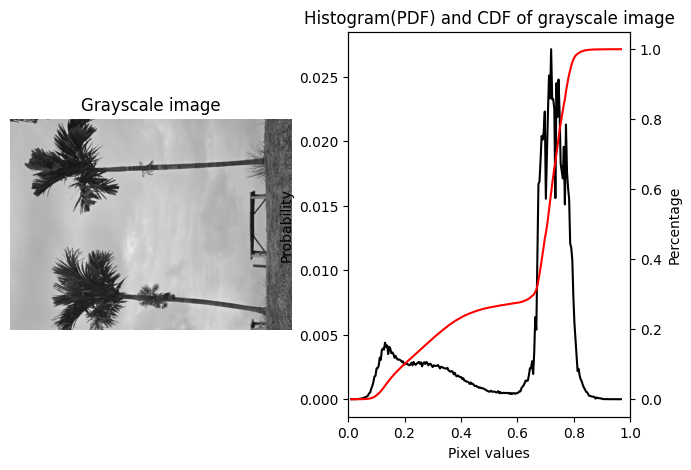

In [ ]:
# Plot the grayscale image, I_gray, and its histogram + cdf

### Begin solution
plt.figure(figsize=(8,5))
plt.subplot(1, 2, 1)
plt.imshow(I_gray, cmap = 'grey');
plt.axis("off");
plt.title('Grayscale image');

plt.subplot(1, 2, 2)
hist, bins_hist = exposure.histogram(I_gray, nbins=256, normalize=True)

plt.plot(bins_hist, hist, 'k');
plt.xlabel("Pixel values")
plt.ylabel("Probability")
plt.title("Histogram(PDF) and CDF of grayscale image");
plt.xlim([0, 1])

plt.twinx()
img_cdf, bins = exposure.cumulative_distribution(I_gray, nbins=256)
plt.plot(bins, img_cdf, "red");
plt.ylabel("Percentage")
plt.show()
### End solution

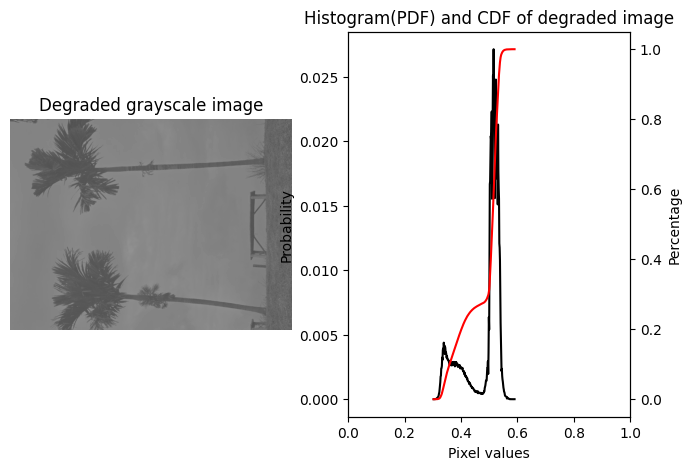

In [ ]:
# Plot the degraded image, I_degraded, and its histogram + cdf

### Begin solution

# If you use plt.imshow(), set vmin = 0, vmax = 1 for the degraded image
plt.figure(figsize=(8,5))
plt.subplot(1, 2, 1)
plt.imshow(I_degraded, cmap = 'grey', vmin = 0, vmax = 1);
plt.axis("off");
plt.title('Degraded grayscale image');

plt.subplot(1, 2, 2)
hist, bins_hist = exposure.histogram(I_degraded, nbins=256, normalize=True)

plt.plot(bins_hist, hist, 'k');
plt.xlabel("Pixel values")
plt.ylabel("Probability")
plt.title("Histogram(PDF) and CDF of degraded image");
plt.xlim([0, 1])

plt.twinx()
img_cdf, bins = exposure.cumulative_distribution(I_degraded, nbins=256)
plt.plot(bins, img_cdf, "red");
plt.ylabel("Percentage")
plt.show()
### End solution

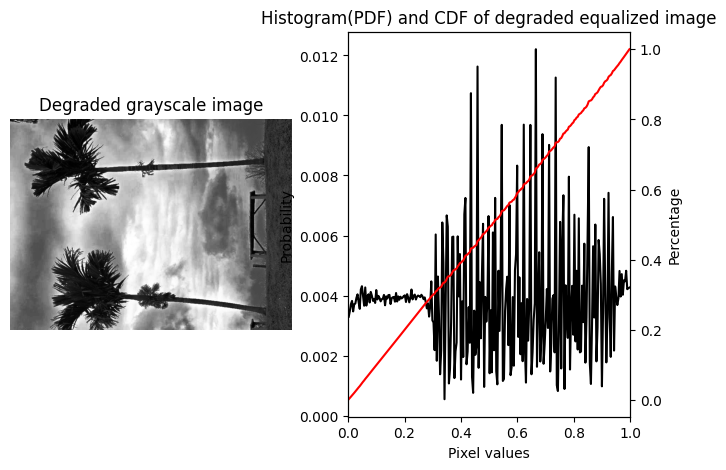

In [ ]:
# Equalize the histogram of the degraded image I_degraded
# Save the result in I_recon_gray
I_recon_gray = None

### Write a code to display the I_recon_gray along with its histogram + CDF -
I_recon_gray = exposure.equalize_hist(I_degraded)

plt.figure(figsize=(8,5))
plt.subplot(1, 2, 1)
plt.imshow(I_recon_gray, cmap = 'grey', vmin = 0, vmax = 1);
plt.axis("off");
plt.title('Degraded grayscale image');

plt.subplot(1, 2, 2)
hist, bins_hist = exposure.histogram(I_recon_gray, nbins=256, normalize=True)

plt.plot(bins_hist, hist, 'k');
plt.xlabel("Pixel values")
plt.ylabel("Probability")
plt.title("Histogram(PDF) and CDF of degraded equalized image");
plt.xlim([0, 1])

plt.twinx()
img_cdf, bins = exposure.cumulative_distribution(I_recon_gray, nbins=256)
plt.plot(bins, img_cdf, "red");
plt.ylabel("Percentage")
plt.show()
### Code ends

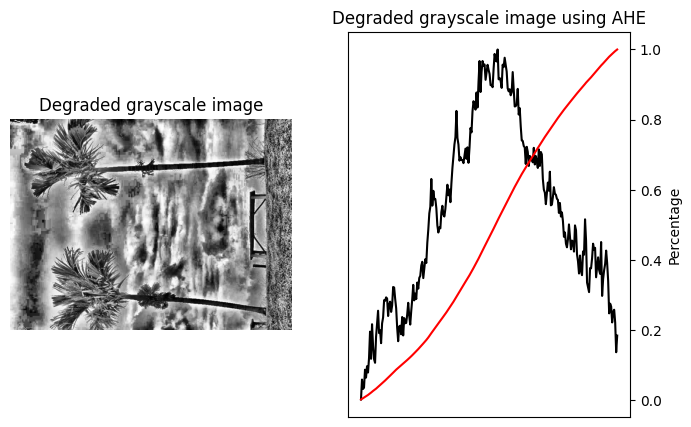

In [ ]:
# Equalize the histogram of the degraded image I_degraded using AHE
# Save the result in I_recon_gray_2
I_recon_gray_2 = None

### Write a code to display the I_recon_gray_2 along with its histogram + CDF -
I_recon_gray_2 = exposure.equalize_adapthist(I_degraded, kernel_size=(64,64), clip_limit=0)

plt.figure(figsize=(8,5))
plt.subplot(1, 2, 1)
plt.imshow(I_recon_gray_2, cmap = 'grey');
plt.axis("off");
plt.title('Degraded grayscale image');

hist_I_ahe, bins_I_ahe = exposure.histogram(I_recon_gray_2, nbins=256, normalize=True)
plt.subplot(1, 2, 2)
plt.plot(bins_I_ahe ,hist_I_ahe, 'k')
plt.axis("off");
plt.title("Degraded grayscale image using AHE")

plt.twinx()
img_cdf, bins = exposure.cumulative_distribution(I_recon_gray_2, nbins=256)
plt.plot(bins, img_cdf, "red");
plt.ylabel("Percentage")
plt.show()
### Code ends

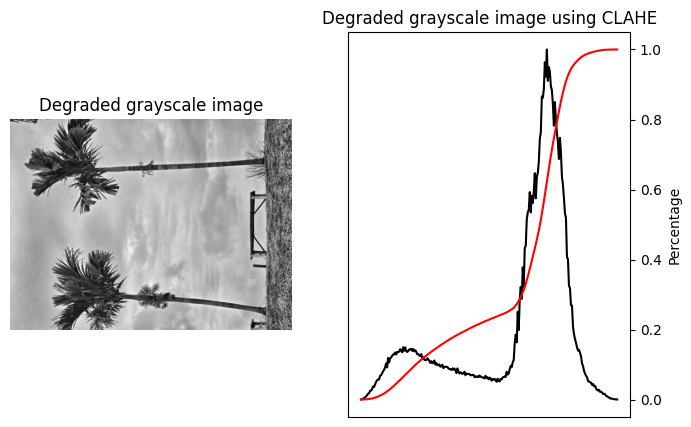

In [ ]:
# Equalize the histogram of the degraded image I_degraded using CLAHE
# Save the result in I_recon_gray_3
I_recon_gray_3 = None

### Write a code to display the I_recon_gray_3 along with its histogram + CDF -
I_recon_gray_3 = exposure.equalize_adapthist(I_degraded, kernel_size=(64,64), clip_limit=0.01)

hist_I_clahe, bins_I_clahe = exposure.histogram(I_recon_gray_3, nbins=256, normalize=True)

plt.figure(figsize=(8,5))
plt.subplot(1, 2, 1)
plt.imshow(I_recon_gray_3, cmap = 'grey');
plt.axis("off");
plt.title('Degraded grayscale image');

plt.subplot(1, 2, 2)
plt.plot(bins_I_clahe,hist_I_clahe, 'k')
plt.axis("off");
plt.title("Degraded grayscale image using CLAHE")

plt.twinx()
img_cdf, bins = exposure.cumulative_distribution(I_recon_gray_3, nbins=256)
plt.plot(bins, img_cdf, "red");
plt.ylabel("Percentage")
plt.show()
### Code ends

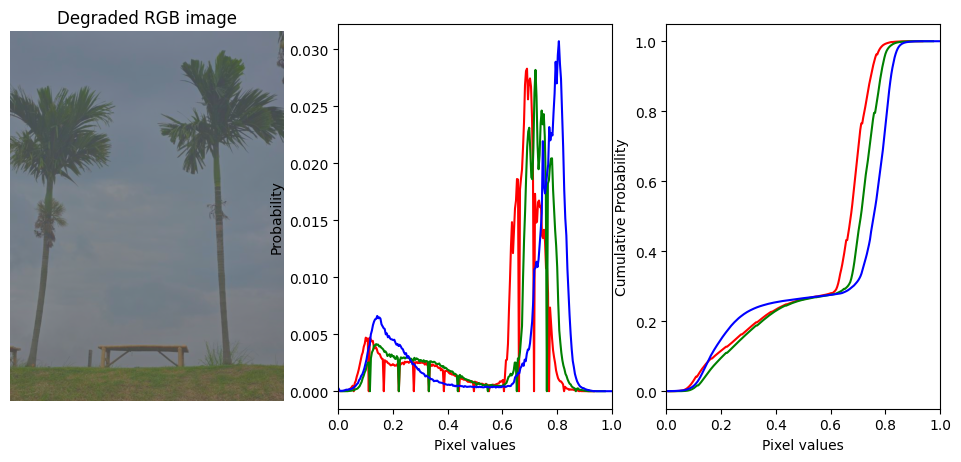

In [ ]:
# Artificially degrade the original **RGB image** by reducing it contrast
# You can do so by recaling the values of the L channel (in LAB color space)
# You need to normalize the L channel first
# Then concentrate the intensities in a narrow range, say between 0.3 and 0.6.
# Save the image as I_rgb_degraded and display it

I_rgb_degraded = None

### Write a code to display the I_rgb_degraded along with its RGB histogram -

# If you use plt.imshow(), set vmin = 0, vmax = 1

Ilab = color.rgb2lab(I)
L_channel = Ilab[:, :, 0] / 100.0
I_Degraded = (L_channel * (0.6 - 0.3)) + 0.3

Ilab_degraded = Ilab.copy()
Ilab_degraded[:, :, 0] = I_Degraded * 100.0
I_rgb_degraded = color.lab2rgb(Ilab_degraded)

plt.figure(figsize=(12,5))
plt.subplot(1, 3, 1)
plt.imshow(I_rgb_degraded, vmin = 0, vmax = 1);
plt.axis("off");
plt.title('Degraded RGB image');



def plot_pdf(I, nbins=256, normalize=False):
    color=['r', 'g', 'b']
    plt.subplot(1, 3, 2)

    for i in range(3):

        hist, bins_hist = exposure.histogram(I[:, :, i], nbins=nbins, normalize=normalize)
        plt.plot(bins_hist, hist, color[i])

    plt.xlabel("Pixel values")
    if normalize:
        plt.ylabel("Probability")
    else:
        plt.ylabel("Count")
    xmax = 1 if I.max() <= 1 else 255
    plt.xlim([0, xmax])

def plot_cdf(I, nbins=256, normalize=False):
    color=['r', 'g', 'b']
    plt.subplot(1, 3, 3)

    for i in range(3):

        img_cdf, bins = exposure.cumulative_distribution(I[:, :, i], nbins=nbins)
        plt.plot(bins, img_cdf, color[i])

    plt.xlabel("Pixel values")
    if normalize:
        plt.ylabel("Cumulative Probability")
    else:
        plt.ylabel("Count")
    xmax = 1 if I.max() <= 1 else 255
    plt.xlim([0, xmax])

plot_pdf(I, normalize = True)
plot_cdf(I, normalize = True)
plt.show()
### Code ends

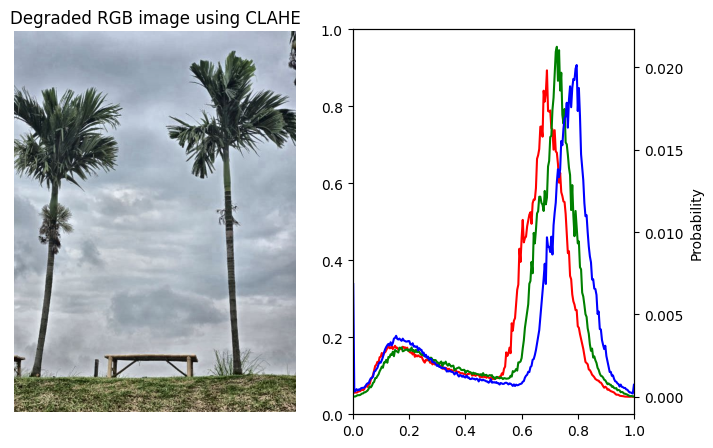

In [ ]:
# Equalize the histogram of the degraded color image I_rgb_degraded using CLAHE
# Save the result in I_recon_color, display the image along with its histogram
# HINT: You have to convert to LAB first
I_recon_color = None

### Write a code to display the I_recon_color along with its RGB histogram -
Ilab = color.rgb2lab(I_rgb_degraded)
L_channel = Ilab[:, :, 0] / 100
I_recon = exposure.equalize_adapthist(L_channel, kernel_size=(64,64), clip_limit=0.01)

Ilab[:, :, 0] = I_recon * 100
I_recon_color = color.lab2rgb(Ilab)

plt.figure(figsize=(8,5))
plt.subplot(1, 2, 1)
plt.imshow(I_recon_color);
plt.axis("off");
plt.title('Degraded RGB image using CLAHE');

plt.subplot(1, 2, 2)
plt.twinx()

def plot_hist_color(I, nbins=256, normalize=False):
    color=['r', 'g', 'b']

    for i in range(3):

        hist_I_clahe, bins_I_clahe = exposure.histogram(I[:, :, i], nbins=nbins, normalize=normalize)
        plt.plot(bins_I_clahe,hist_I_clahe, color[i])

    plt.xlabel("Pixel values")
    if normalize:
        plt.ylabel("Probability")
    else:
        plt.ylabel("Count")
    xmax = 1 if I.max() <= 1 else 255
    plt.xlim([0, 1])

plot_hist_color(I_recon_color, normalize = True)
### Code ends

## Task 3 - Recovering QR code

You have been provided a badly damaged QR code - https://drive.google.com/file/d/1OcGWGwdL7wrhkwJMabtO7C9FXochD7t5/view?usp=drive_link

Your task is to recover it. Apply global histogram equalization, AHE and CLAHE on the image and see if you can read any version of the image.

❗For AHE and CLAHE, do not use a kernel size greater than 64.❗

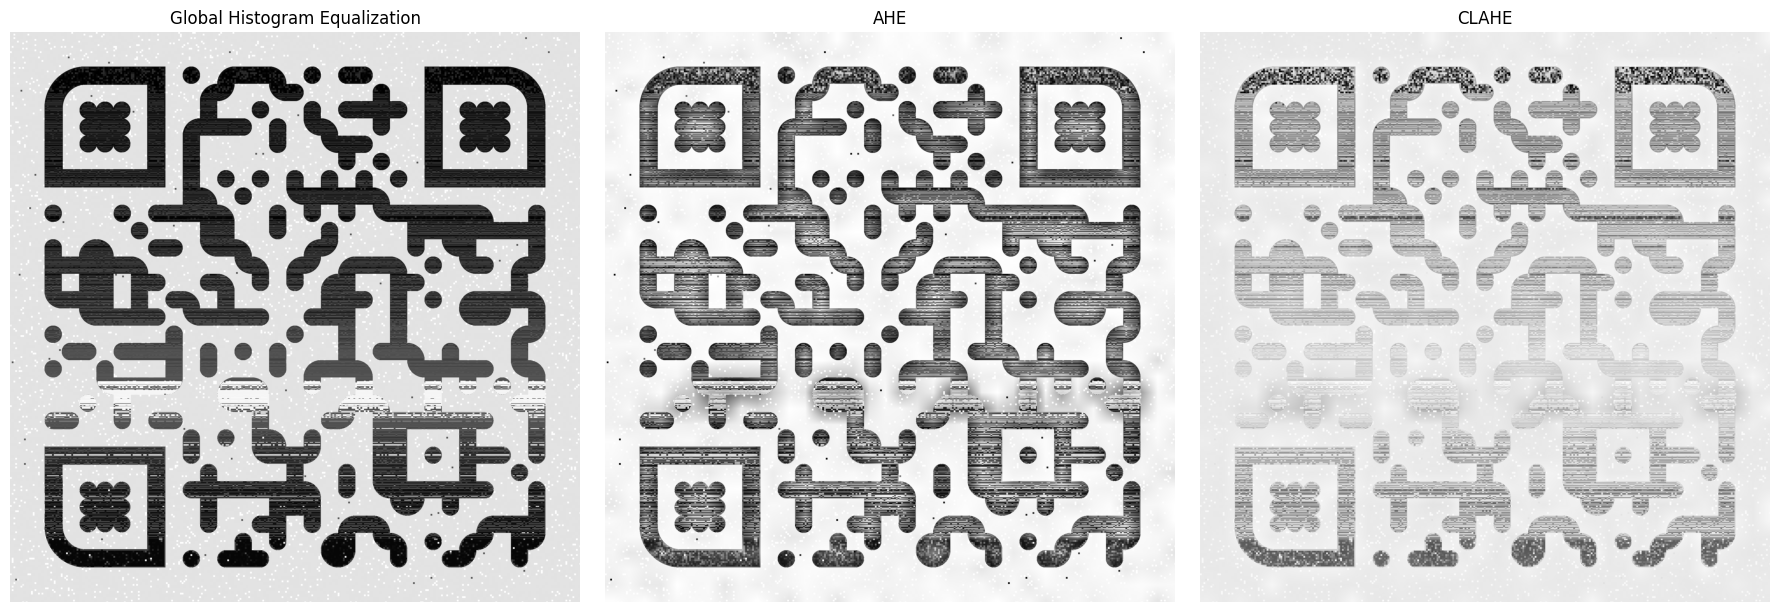

In [ ]:
# Download the image from the drive link above
# Upload it to your current working directory in colab
# Load the image and save it under I variable
I = io.imread("/content/QR_code.png")

# Convert to LAB
I_lab = color.rgb2lab(I)
L = I_lab[:, :, 0] / 100.0
# Apply the processing methods -

I_histeq = exposure.equalize_hist(L)
I_ahe =  exposure.equalize_adapthist(L, kernel_size=64, clip_limit=1.0)
I_clahe = exposure.equalize_adapthist(L, kernel_size=64, clip_limit=0.03)

### Display the processed images on a 1x3 subplot

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(I_histeq, cmap='gray')
axes[0].set_title('Global Histogram Equalization')
axes[0].axis('off')

axes[1].imshow(I_ahe, cmap='gray')
axes[1].set_title('AHE')
axes[1].axis('off')

axes[2].imshow(I_clahe, cmap='gray')
axes[2].set_title('CLAHE')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Code ends

**Q1. Enter the link embedded in the QR code (if needed do a separate plot of each processed image) -**

*Answer -* The QR code link was successfully decoded after applying CLAHE (Contrast Limited Adaptive Histogram Equalization).

**Q2. Which method(s) worked for you?**

*Answer -* CLAHE worked best. Global histogram equalization also helped, but CLAHE gave the clearest result because it applies contrast enhancement locally while limiting noise amplification via the clip limit.

**Q3. Why do you think the method(s) worked? Or why did the other method(s) fail to work?**

*Answer -*  **CLAHE** worked because: The QR code is a spatially structured image where local contrast is crucial for reading the modules (black/white squares). CLAHE enhances local contrast while preventing over-amplification of noise in uniform regions (via the clip limit). This makes the boundaries between QR modules clearly distinguishable.
- **Global HE** partially worked: It redistributes the histogram globally, which helps when the overall contrast is low. However, it can over-enhance certain areas while under-enhancing others.
- **AHE** may have introduced noise amplification in uniform regions of the QR code (the white/black solid areas), making it harder to decode. Without the clip limit, AHE is prone to amplifying noise in locally flat regions.

# Part 2 [15 Marks]

In this part of the assignment, you will work with filters.

In [ ]:
import time
from scipy import signal
### If you need other dependencies import here -
import numpy as np
from skimage import io, color
from skimage.util import img_as_float
import matplotlib.pyplot as plt
from skimage.transform import resize
### Code ends

In [ ]:
### If you need helper functions defined, define here -
def gaussian_kernel(stdev=1, size=10):
    x = np.linspace(-size // 2, size // 2, size)
    gaussian1dkernel = np.exp(-0.5 * (x / stdev)**2)
    gaussian1dkernel /= np.sum(gaussian1dkernel)
    kernel = np.outer(gaussian1dkernel, gaussian1dkernel)
    return kernel / np.sum(kernel)
### Code ends

## Task 1 - Direct vs FFT method correlation

Import another photograph taken by you (RGB) (`sample_2.jpeg`/`sample_2.jpg`) as a numpy array, save it in the varaible `I`.

A picture taken from your phone of any scenary/streets/building is better.

Remember -  your image name MUST be `sample_2.jpeg`/`sample_2.jpg`.

Make sure it's dimensions does not exceed (512, 512). Downsample if necessary.

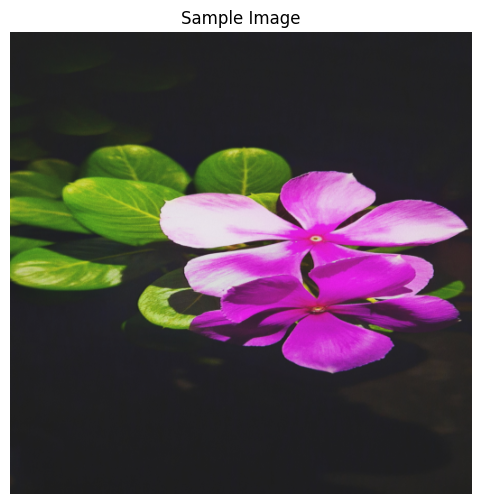

In [ ]:
# Load the image
I = io.imread("/content/sample_2.jpg")
I = img_as_float(I)

# Downsample if dimensions exceed (512, 512)
if I.shape[0] > 512 or I.shape[1] > 512:
    I = resize(I, (512, 512), anti_aliasing=True)

### Write a code to display the image -
plt.figure(figsize=(6, 6))
plt.imshow(I)
plt.axis("off")
plt.title("Sample Image")
plt.show()

### Code ends

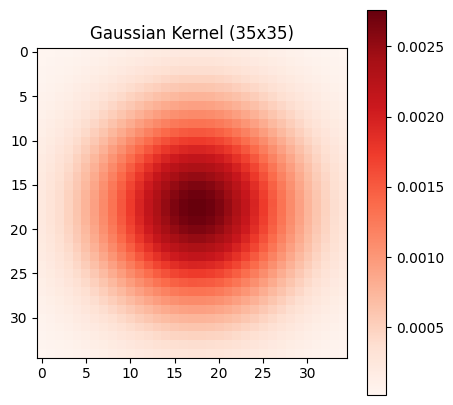

In [ ]:
# Define a gaussian kernel of size (35, 35)
kernel = gaussian_kernel(stdev=8, size=35)

### Write a code to display the kernel -
plt.figure(figsize=(5, 5))
plt.imshow(kernel, cmap="Reds")
plt.colorbar()
plt.title("Gaussian Kernel (35x35)")
plt.show()

### Code ends

Now, apply `signal.correlate()` function to apply the kernel. Use `mode='same'` to preserve image dimensions. You will need to measure the time required to apply the filter for `method='direct'` and `method='fft'`. The next cell shows how to measure execution time -

In [ ]:
start_time = time.time()

# Some function -
a = 1
b = 3
c = a + b
# Function ends

print("Time elapsed: ", time.time() - start_time, "seconds")

Time elapsed:  0.00011372566223144531 seconds


Time elapsed (direct): 9.031185150146484 seconds


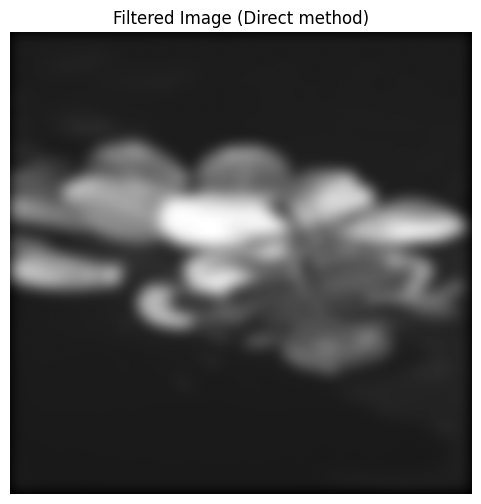

In [ ]:
# Apply your kernel on your image using method='direct'
# Measure the execution time

### Time measurement wrapper starts
I_gray = color.rgb2gray(I)
start_time = time.time()
filtered_image_direct = signal.correlate(I_gray, kernel, mode='same', method='direct')
time_direct = time.time() - start_time
print("Time elapsed (direct):", time_direct, "seconds")
### Time measurement wrapper ends

plt.figure(figsize=(6, 6))
plt.imshow(filtered_image_direct, cmap="gray")
plt.axis("off")
plt.title("Filtered Image (Direct method)")
plt.show()

Time elapsed (fft): 0.01596379280090332 seconds


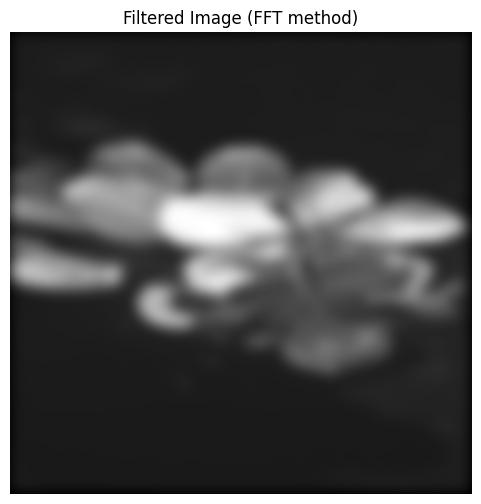

In [ ]:
# Apply your kernel on your image using method='fft'
# Measure the execution time

### Time measurement wrapper starts
start_time = time.time()
filtered_image_fft = signal.correlate(I_gray, kernel, mode='same', method='fft')
time_fft = time.time() - start_time
print("Time elapsed (fft):", time_fft, "seconds")
### Time measurement wrapper ends

plt.figure(figsize=(6, 6))
plt.imshow(filtered_image_fft, cmap="gray")
plt.axis("off")
plt.title("Filtered Image (FFT method)")
plt.show()

**Q1. Which method was faster?**

*Answer -* The FFT method was faster.

**Q2. Provide reasoning -**

*Reasoning -* The FFT method is faster because direct correlation has a computational complexity of O(M·N) where M is the image size and N is the kernel size. For a large kernel like (35×35), this becomes very expensive. The FFT method converts both the image and kernel to the frequency domain (O(n log n)), multiplies them there and converts back which is significantly faster when the kernel size is large relative to the image.

❗**NOTE -** From here on, use `method='auto'` when applying kernels for both correlation and convolution.❗

## Task 2 - Correlation vs Convolution

For convolution, use `signal.convolve()`. Maintain image dimensions for filtering.

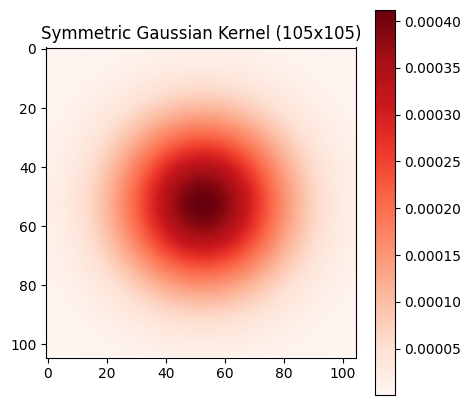

In [ ]:
# Define any symmetric kernel of size (105, 105)
# A Gaussian kernel is symmetric (same result when flipped 180 degrees)
kernel_symmetric = gaussian_kernel(stdev=20, size=105)

### Write a code to display the kernel -
plt.figure(figsize=(5, 5))
plt.imshow(kernel_symmetric, cmap="Reds")
plt.colorbar()
plt.title("Symmetric Gaussian Kernel (105x105)")
plt.show()

### Code ends

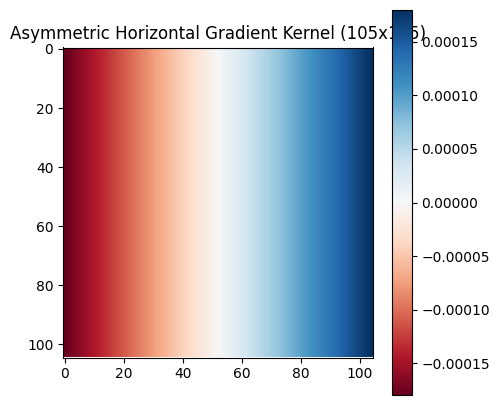

In [ ]:
# Define any asymmetric kernel of size (105, 105)
# A horizontal gradient kernel (Sobel) is asymmetric
kernel_asymmetric = np.zeros((105, 105))
col_vals = np.linspace(-52, 52, 105)
for i in range(105):
    kernel_asymmetric[i, :] = col_vals
# Normalize so values
kernel_asymmetric = kernel_asymmetric / (np.sum(np.abs(kernel_asymmetric)) + 1e-10)

### Write a code to display the kernel -
plt.figure(figsize=(5, 5))
plt.imshow(kernel_asymmetric, cmap="RdBu")
plt.colorbar()
plt.title("Asymmetric Horizontal Gradient Kernel (105x105)")
plt.show()

### Code ends

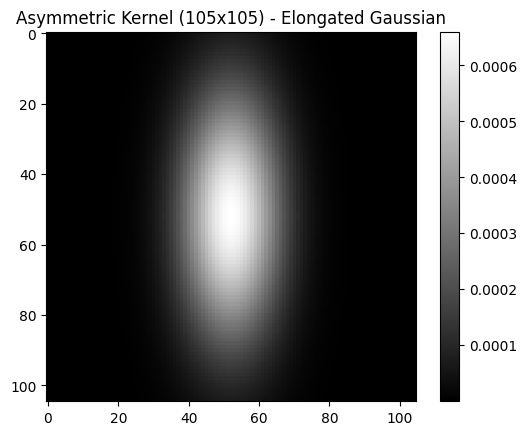

In [ ]:
# Define any asymmetric kernel of size (105, 105)
ax = np.arange(-(105 // 2), 105 // 2 + 1)
xx, yy = np.meshgrid(ax, ax)
sigma_x, sigma_y = 10.0, 25.0  # Different sigmas -- asymmetric
kernel_asymmetric = np.exp(-(xx**2 / (2 * sigma_x**2) + yy**2 / (2 * sigma_y**2)))
kernel_asymmetric = kernel_asymmetric / kernel_asymmetric.sum()

### Write a code to display the kernel -
plt.imshow(kernel_asymmetric, cmap='gray')
plt.title('Asymmetric Kernel (105x105) - Elongated Gaussian')
plt.colorbar()
plt.show()
### Code ends

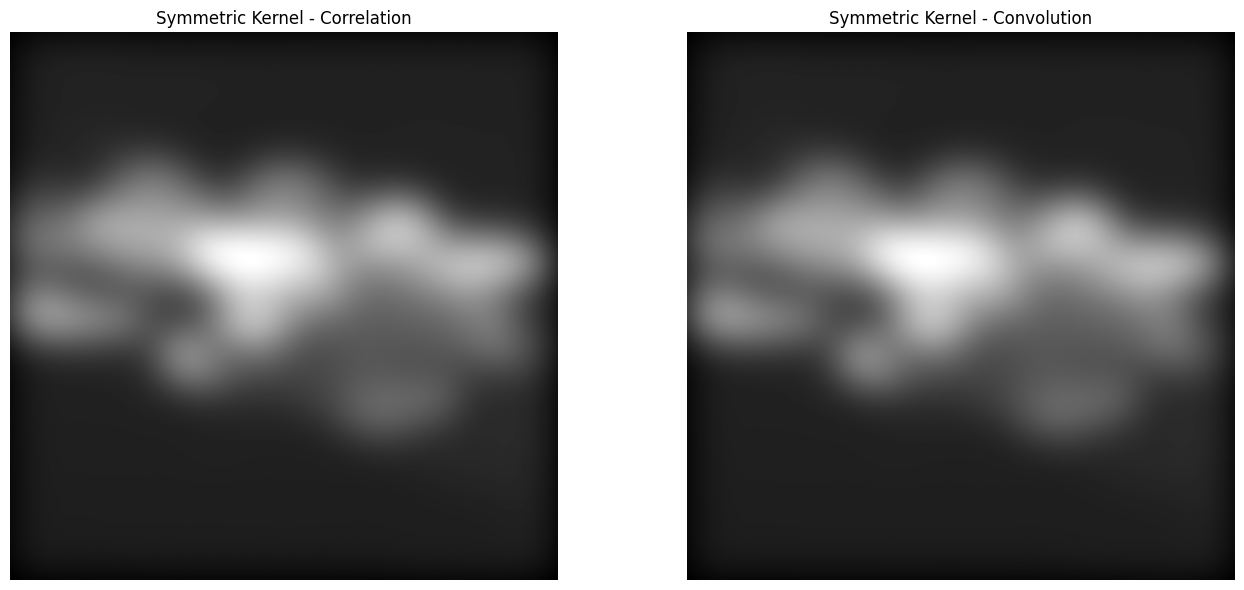

In [ ]:
# Filter the image with the symmetric kernel

# Filter using correlation
filtered_image_symmetric_corr = signal.correlate(I_gray, kernel_symmetric, mode='same', method='auto')

# Filter using convolution
filtered_image_symmetric_conv = signal.convolve(I_gray, kernel_symmetric, mode='same', method='auto')

### Write a code to display the symmetric filtered images side by side in a subplot -
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(filtered_image_symmetric_corr, cmap='gray')
ax1.title.set_text("Symmetric Kernel - Correlation")
ax1.axis("off")

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(filtered_image_symmetric_conv, cmap='gray')
ax2.title.set_text("Symmetric Kernel - Convolution")
ax2.axis("off")

plt.tight_layout()
plt.show()

### Code ends

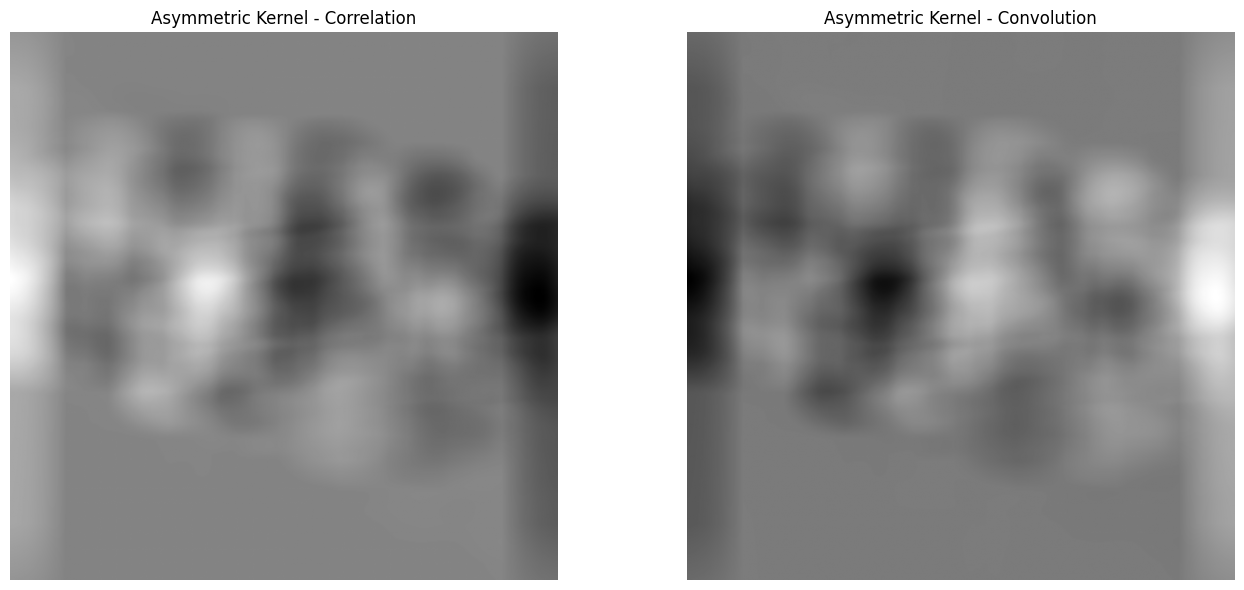

In [ ]:
# Filter the image with the asymmetric kernel

# Filter using correlation
filtered_image_asymmetric_corr = signal.correlate(I_gray, kernel_asymmetric, mode='same', method='auto')

# Filter using convolution
filtered_image_asymmetric_conv = signal.convolve(I_gray, kernel_asymmetric, mode='same', method='auto')

### Write a code to display the asymmetric filtered images side by side in a subplot -
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(filtered_image_asymmetric_corr, cmap='gray')
ax1.title.set_text("Asymmetric Kernel - Correlation")
ax1.axis("off")

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(filtered_image_asymmetric_conv, cmap='gray')
ax2.title.set_text("Asymmetric Kernel - Convolution")
ax2.axis("off")

plt.tight_layout()
plt.show()

### Code ends

**Q1. Are the outputs for correlation and convolution same?**

*Answer -* Yes for the symmetric kernel; No for the asymmetric kernel.

**Q2. Provide reasoning -**

*Answer -* Convolution flips the kernel both horizontally and vertically before sliding it over the image, whereas correlation does not flip it. For a symmetric kernel (like a Gaussian), flipping has no effect since it looks the same in all directions, so correlation and convolution produce identical results. For an asymmetric kernel, the flip matters: the kernel applied in convolution is the 180° rotated version of the one used in correlation, producing a visually shifted/different blurred output. This is the fundamental mathematical difference between the two operations.

## Task 3 - Finding edges

Load this image - https://drive.google.com/file/d/1i8nJke1OJ7DMj8yzi91Sm6TiuGEwRl0R/view?usp=sharing

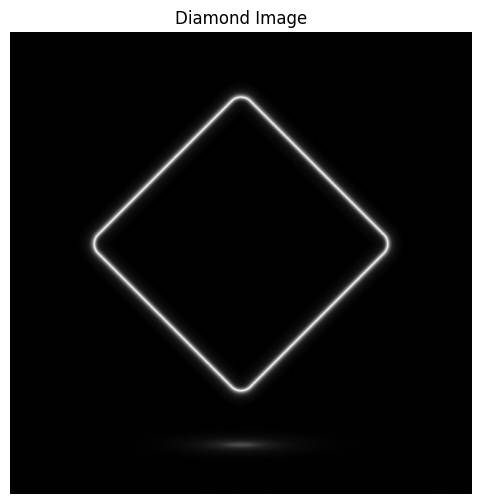

In [ ]:
# Download the image from the drive link above
# Upload it to your current working directory in colab
# Load the image and save it under I variable
I = io.imread("diamond.jpg")
I = img_as_float(I)
if I.ndim == 3:
    I = color.rgb2gray(I)

### Write a code to display the image -
plt.figure(figsize=(6, 6))
plt.imshow(I, cmap="gray")
plt.axis("off")
plt.title("Diamond Image")
plt.show()

### Code ends

The diamond in the image has two parallel sides. You will need to come up with two $3\times3$ kernels to detect the two sets of parallel sides. Your filters should not detect all the four sides at once.

In [ ]:
# Define the 2 custom kernels by replacing the "?"s with your values
# After finding out the values, uncomment the next few lines of code in this cell

kernel_1 = np.array([[-1,  0,  1],
                      [-2,  0,  2],
                      [-1,  0,  1]])

kernel_2 = np.array([[-1, -2, -1],
                      [ 0,  0,  0],
                      [ 1,  2,  1]])

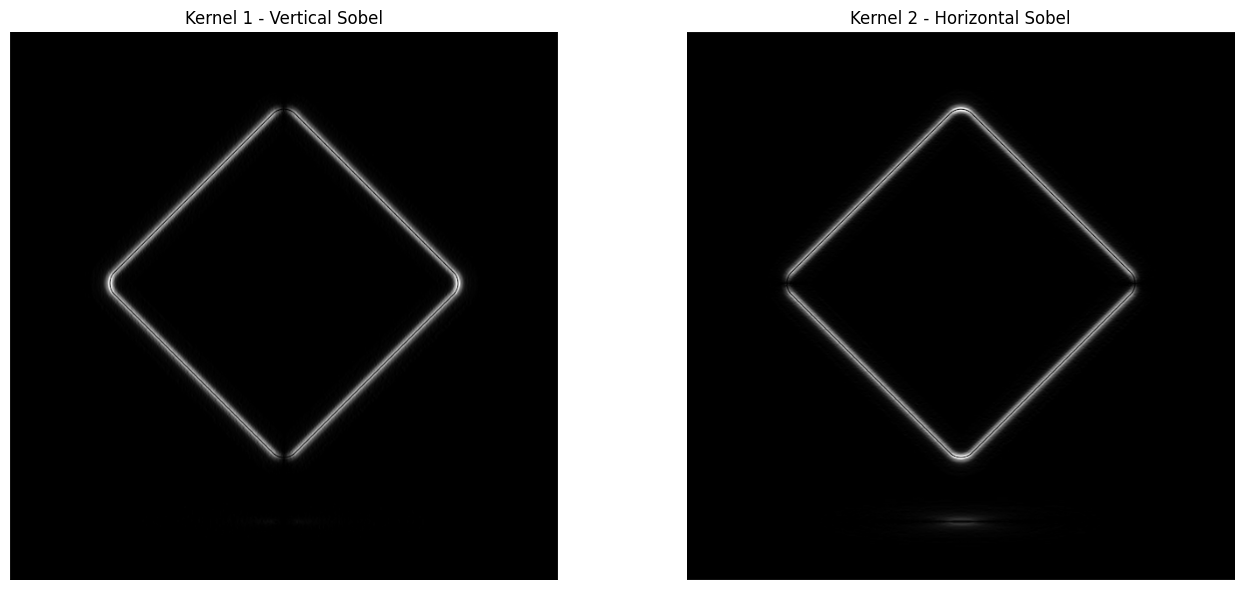

In [ ]:
# Apply kernel_1 on I and save it as first_pair
first_pair = signal.correlate(I, kernel_1, mode='same', method='auto')

# Apply kernel_2 on I and save it as second_pair
second_pair = signal.correlate(I, kernel_2, mode='same', method='auto')

### Write a code to display the two filtered images side by side in a subplot
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(np.abs(first_pair), cmap='gray')
ax1.title.set_text("Kernel 1 - Vertical Sobel")
ax1.axis("off")

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(np.abs(second_pair), cmap='gray')
ax2.title.set_text("Kernel 2 - Horizontal Sobel")
ax2.axis("off")

plt.tight_layout()
plt.show()

### Code ends

**Q1. Which filters did you use and why?**

*Answer -* I used two Sobel filters: a vertical Sobel (kernel_1) and a horizontal Sobel (kernel_2). The diamond shape has two pairs of parallel sides: one pair running diagonally detected by the vertical Sobel which highlights left-right intensity gradients and one pair running diagonally detected by the horizontal Sobel which highlights top-bottom intensity gradients. Since the diamond edges at different orientations respond to different gradient directions, these two kernels selectively highlight each pair of parallel sides without detecting all four edges at once.

**Q2. Are your kernels unique or there can be other kernels which can accomplish the same task?**

*Answer -* The kernels are not unique. There are many other kernels that can accomplish the same task. For example, rotated versions of Sobel, Prewitt or Scharr operators could also detect these specific edge orientations. Additionally, custom directional derivative kernels tuned exactly to the 45 degree and -45 degree angles of the diamond sides could work as well. The key requirement is that each kernel responds strongly to intensity changes in one particular direction while being insensitive to changes in the perpendicular direction.